In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [29]:
train_data = fetch_20newsgroups(
    subset = "train",
    remove = ("headers","footers","quotes")
)
test_data = fetch_20newsgroups(
    subset = "test",
    remove = ("headers","footers","quotes")
)

In [30]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [31]:
print("Training Data: ", len(X_train_text))
print("Testing Data: ", len(X_test_text))
print("Number of classes: ", len(class_names))

Training Data:  11314
Testing Data:  7532
Number of classes:  20


In [32]:
vectorizer = CountVectorizer(
stop_words = "english",
min_df= 2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [33]:
print("Number of features: ", X_train.shape[1])
print("Number of training samples: ", X_train.shape[0])

Number of features:  39115
Number of training samples:  11314


In [34]:
mnb = MultinomialNB()

mnb.fit(X_train, y_train)

y_pred_mnb = mnb.predict(X_test)

In [35]:
binary_vectorizer = CountVectorizer(
stop_words = "english",
min_df= 2,
binary = True
)

X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)

X_test_binary = binary_vectorizer.transform(
    X_test_text
)

In [36]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)

y_pred_bnb = bnb.predict(
    X_test_binary
)

In [39]:
results = pd.DataFrame({
    "Model": [
        "MultinomialNB",
        "BernoulliNB"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_mnb),
        accuracy_score(y_test, y_pred_bnb)
    ],

    "Precision": [
        precision_score(
            y_test, 
            y_pred_mnb, 
            average = "macro"
        ),
        precision_score(
            y_test, 
            y_pred_bnb, 
            average = "macro"
        )
    ],
    "Recall": [
        recall_score(
            y_test, 
            y_pred_mnb, 
            average = "macro"
        ),
        recall_score(
            y_test, 
            y_pred_bnb, 
            average = "macro"
        )
    ],
    "F1-Score": [
        f1_score(
            y_test, 
            y_pred_mnb, 
            average = "macro"
        ),
        f1_score(
            y_test, 
            y_pred_bnb, 
            average = "macro"
        )
    ]
})

In [41]:
results

,Model,Accuracy,Precision,Recall,F1-Score
0,MultinomialNB,0.651089,0.634470,0.636933,0.617859
1,BernoulliNB,0.485130,0.616678,0.469434,0.467865


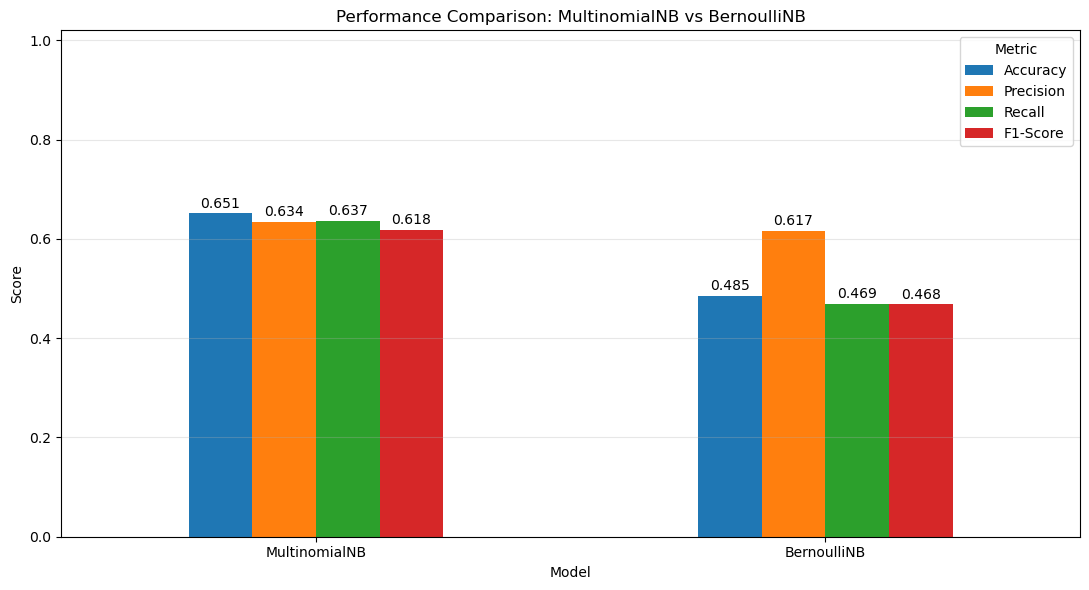

In [44]:
results_metrics = results[["Model", "Accuracy", "Precision", "Recall", "F1-Score"]]

ax = results_metrics.set_index("Model").plot(
    kind = "bar",
    figsize = (11, 6), 
)

plt.title("Performance Comparison: MultinomialNB vs BernoulliNB")

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1.02)
plt.xticks(rotation = 0)
plt.legend(title = "Metric")

plt.grid(
    axis = "y",
    alpha = 0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt = "%.3f",
        padding = 2
    )

plt.tight_layout()
plt.show()